# Joint Recurrence Plots Analysis - Phase Synchronization

## Samuel Jaramillo

### Research question
1. Compare the recurrence plot methods for detecting phase, generalised, and complete synchronisation (lag synchronisation is included).

2. Prepare an overview of the ability of the measures derived from cross- and joint recurrence plots and from tau-recurrence rate.

3. (Bonus) improve the tau-recurrence rate measure (CPR).

In [1]:
import numpy as np
import pandas as pd
import recurrence as rec
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.integrate import solve_ivp
import string
from tqdm import tqdm

# we can use the pyunicorn classes for all types of recurrence plots for convenience
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot

In [2]:
#Import models
nosynch1 = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/timeseries/PS_nosynch1.csv').to_numpy()

nosynch2 = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/timeseries/PS_nosynch2.csv').to_numpy()

synch1 = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/timeseries/PS_synch1.csv').to_numpy()

synch2 = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/timeseries/PS_synch2.csv').to_numpy()

In [3]:
#View the individual recurrence plots
#No synch
rec_nosynch1 = RecurrencePlot(nosynch1, recurrence_rate=0.1, metric="euclidean")
rm_nosynch1 = rec_nosynch1.recurrence_matrix()

rec_nosynch2 = RecurrencePlot(nosynch2, recurrence_rate=0.1, metric="euclidean")
rm_nosynch2 = rec_nosynch2.recurrence_matrix()

#Synch
rec_synch1 = RecurrencePlot(synch1, recurrence_rate=0.1, metric="euclidean")
rm_synch1 = rec_synch1.recurrence_matrix()

rec_synch2 = RecurrencePlot(synch2, recurrence_rate=0.1, metric="euclidean")
rm_synch2 = rec_synch2.recurrence_matrix()

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


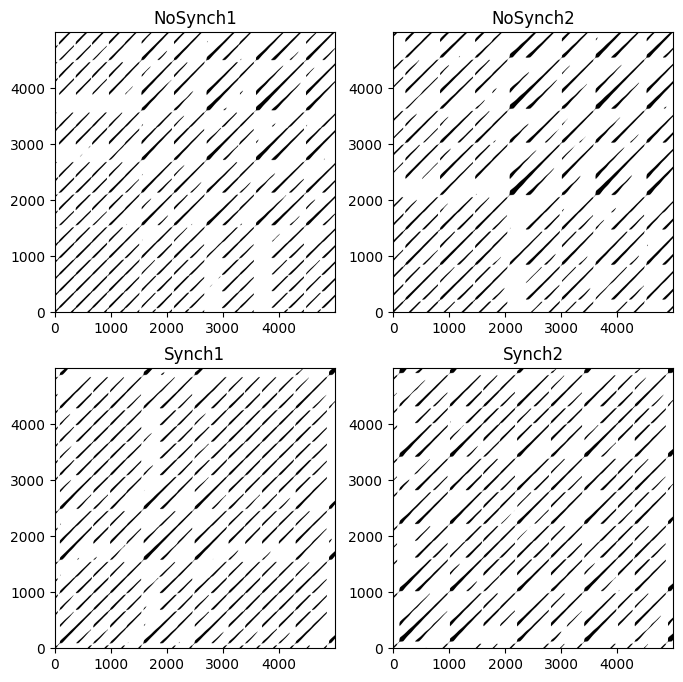

In [4]:
#Visualize
fig, axs = plt.subplots(2,2,figsize=(8, 8))

#Plot
RP_comparison_list = [rm_nosynch1, rm_nosynch2, rm_synch1, rm_synch2]
RP_comparison_titles = ['NoSynch1', 'NoSynch2', 'Synch1', 'Synch2']

l = 0
for i in range(2):
    for j in range(2):
        axs[i][j].imshow(RP_comparison_list[l], origin='lower', cmap = 'binary')
        axs[i][j].set_title(RP_comparison_titles[l])

        l += 1

plt.show()

In [5]:
#Compute JRPs
#No synch
LS_JR_nosynch = JointRecurrencePlot(nosynch1, nosynch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"))

RMat_LS_nosynch = LS_JR_nosynch.recurrence_matrix()

#Synch
LS_JR_synch = JointRecurrencePlot(synch1, synch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"))

RMat_LS_synch = LS_JR_synch.recurrence_matrix()

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...


In [6]:
#Find lag with max S(tau)
lagged_JR_synch = [JointRecurrencePlot(synch1, synch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = i) for i in range(60)]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

In [7]:
s_tau_synch = [lagged_JR_synch[i].recurrence_rate()/0.1 for i in range(len(lagged_JR_synch))]

In [8]:
max_lag = np.where(np.array(s_tau_synch) == max(s_tau_synch))[0][0]

max_JRP_tau = lagged_JR_synch[max_lag]

RMat_max_JRP_tau  = max_JRP_tau.recurrence_matrix()

In [9]:
#Print S(tau) values for non-synched, synched and max synched models
print('JRP NoSynch', LS_JR_nosynch.recurrence_rate()/0.1)
print('JRP(0)',s_tau_synch[0])
print('JRP(tau)',max(s_tau_synch))

JRP NoSynch 0.1918096
JRP(0) 0.5718344
JRP(tau) 0.5978192


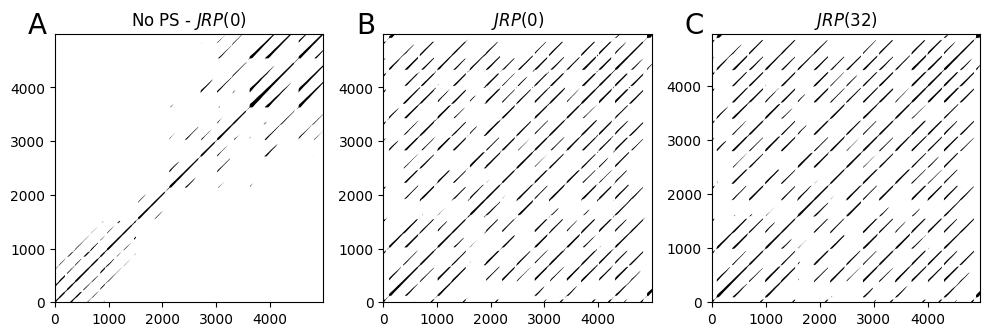

In [10]:
#Visualize
fig, axs = plt.subplots(1,3,figsize=(10, 4))

axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title(r'No PS - $JRP(0)$')
axs[0].text(-0.1, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title(r'$JRP(0)$')
axs[1].text(-0.1, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)

axs[2].imshow(RMat_max_JRP_tau, origin='lower', cmap = 'binary')
axs[2].set_title(r'$JRP({})$'.format(max_lag))
axs[2].text(-0.1, 1, string.ascii_uppercase[2], transform=axs[2].transAxes, 
            size=20)


plt.tight_layout()

plt.show()
#fig.savefig('plots/JRPs_PS.pdf', dpi=300)

Evaluation of sensitivity of $S(\tau)$ to coupling

In [11]:
#Import model
#Mutually coupled Roessler systems
#taken from Marwan (2007), eqs. A.9 and A.10
def coupled_Roessler(t, X, a, b, c, nu, mu):
    """
    X is a flattened vector [x1, x2, x3, y1, y2, y3].
    x corresponds to the first system, y corresponds to the 
    second one. 
    """
    dX = np.zeros(len(X))

    #First system (A.9)
    dX[0] = -(1 + nu)*X[1] - X[2]
    dX[1] = (1 + nu)*X[0] + a*X[1] + mu*(X[4] - X[1])
    dX[2] = b + X[2]*(X[0] - c)

    #Second system (A.10)
    dX[3] = -(1 - nu)*X[4] - X[5]
    dX[4] = (1 - nu)*X[3] + a*X[4] + mu*(X[1] - X[4])
    dX[5] = b + X[5]*(X[3] - c)

    return dX

In [12]:
# Parametres phase coherent regime
# Marwan (2007, p. 290)


a, b, c = 0.16, 0.1, 8.5
#a, b, c = 0.2, 0.2, 5.7
nu = 0.02
mu = np.arange(0,0.15,0.002)


"""
a, b, c = 0.2925, 0.1, 8.5
nu = 0.02
mu = 0.2
"""

#Timestep and length not specified in paper
"""
1000 time steps was to short to show behaviour. We let it stabilize
for 5000 timesteps and use the remaining 10000
"""
T = 15000*0.02  #
dt = 0.02 #Bigger dt gave too rough of a plot
#dt = 0.04 #Bigger dt gave too rough of a plot

In [13]:
# Numerically Integrate The System States
#Initial conditions not specified
X0 = [0,0,0,0,0,0]

t_span = (0, T)
t_eval = np.arange(0, T, dt)

sols = [solve_ivp(coupled_Roessler, t_span, X0, t_eval=t_eval, args=(a, b, c, nu, mu[i]), method="RK45") for i in range(len(mu))]

In [14]:
#Separate models
synch1_varied_coupling = [sols[i].y[:3].T[10000:] for i in range(len(sols))]
synch2_varied_coupling = [sols[i].y[3:].T[10000:] for i in range(len(sols))]

The code block below was used to compute the JPR values for the different coupling values. Due to the time it took to compute, we import directly the result and leave the code inside quotation marks.

In [15]:
'''
from tqdm import tqdm

JPR_list = []

lags = np.arange(0,50,2)

for i in tqdm(range(len(synch1_varied_coupling))):
    #We already know around where Smax is reached
    #lagged_JR_synch_i = [JointRecurrencePlot(synch1_varied_coupling[i], synch2_varied_coupling[i], recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = j) for j in range(30)]
    lagged_JR_synch_i = [JointRecurrencePlot(synch1_varied_coupling[i], synch2_varied_coupling[i], recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = j) for j in lags]
    s_tau_synch_i = np.array([lagged_JR_synch_i[k].recurrence_rate()/0.1 for k in range(len(lagged_JR_synch_i))])


    JPR_i = (np.max(s_tau_synch_i) - 0.1)/(1 - 0.1)

    JPR_list.append(JPR_i)
'''

'\nfrom tqdm import tqdm\n\nJPR_list = []\n\nlags = np.arange(0,50,2)\n\nfor i in tqdm(range(len(synch1_varied_coupling))):\n    #We already know around where Smax is reached\n    #lagged_JR_synch_i = [JointRecurrencePlot(synch1_varied_coupling[i], synch2_varied_coupling[i], recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = j) for j in range(30)]\n    lagged_JR_synch_i = [JointRecurrencePlot(synch1_varied_coupling[i], synch2_varied_coupling[i], recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = j) for j in lags]\n    s_tau_synch_i = np.array([lagged_JR_synch_i[k].recurrence_rate()/0.1 for k in range(len(lagged_JR_synch_i))])\n\n\n    JPR_i = (np.max(s_tau_synch_i) - 0.1)/(1 - 0.1)\n\n    JPR_list.append(JPR_i)\n'

In [16]:
'''
#Save to avoid computing it again
JPR_list_saved = pd.DataFrame(JPR_list)

# save the dataframe as a csv file
JPR_list_saved.to_csv("PS_JPR_list.csv", index=False)
'''

'\n#Save to avoid computing it again\nJPR_list_saved = pd.DataFrame(JPR_list)\n\n# save the dataframe as a csv file\nJPR_list_saved.to_csv("PS_JPR_list.csv", index=False)\n'

In [17]:
#Import models
JPR_list = pd.read_csv('/Users/samuel/Documents/Maestría/WiSe25/Nonlinear Data Analysis/samueljaramillonda/FinalProject_Code/PS_JPR_list.csv').to_numpy()

In [18]:
#Compute CPR values with different couplings
CPR_list = []

for i in tqdm(range(len(mu))):

    rp_drive = RecurrencePlot(synch1_varied_coupling[i], metric="euclidean", recurrence_rate=0.1)
    rp_response = RecurrencePlot(synch2_varied_coupling[i], metric="euclidean", recurrence_rate=0.1)

    RP_drive = rp_drive.recurrence_matrix()
    RP_response = rp_response.recurrence_matrix()

    C = rec.cpr(RP_drive, RP_response)

    CPR_list.append(C)

  0%|          | 0/75 [00:00<?, ?it/s]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


  1%|▏         | 1/75 [00:04<05:03,  4.10s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


  3%|▎         | 2/75 [00:08<05:02,  4.15s/it]

...

 97%|█████████▋| 73/75 [05:01<00:08,  4.43s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


 99%|█████████▊| 74/75 [05:06<00:04,  4.36s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


100%|██████████| 75/75 [05:10<00:00,  4.14s/it]


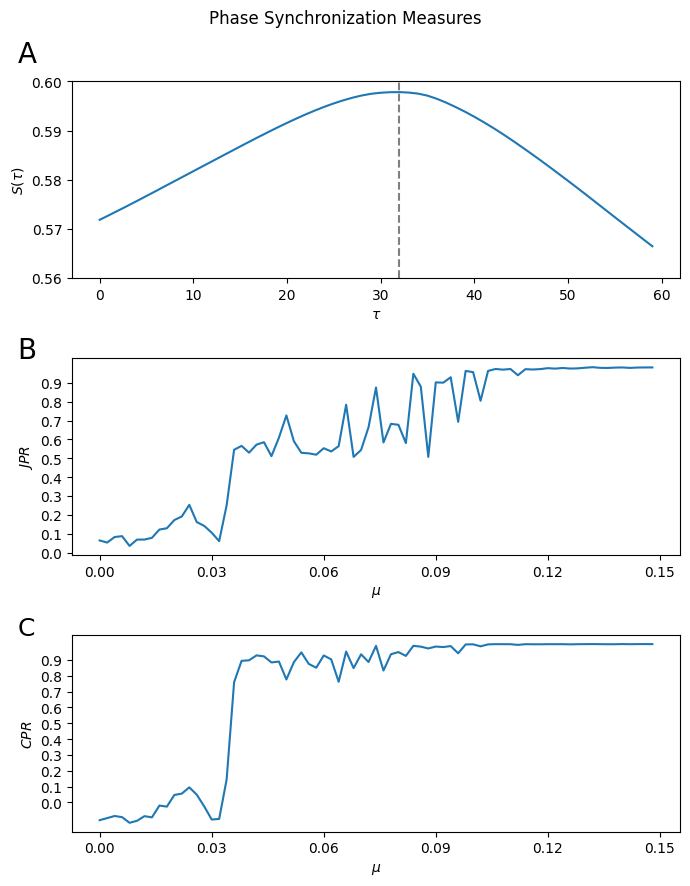

In [19]:
#Phase Synchronization Measures Plot
fig, axs = plt.subplots(3,1,figsize=(7, 9))

#S tau
axs[0].plot(s_tau_synch)
axs[0].set_xlabel(r'$\tau$')
axs[0].set_ylabel(r'$S(\tau)$')
axs[0].set_yticks(np.arange(0.56,0.61,0.01))
axs[0].axvline(max_lag, ls = '--', color = 'gray')
axs[0].text(-0.09, 1.1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

#JPR
axs[1].plot(mu,JPR_list)
axs[1].set_yticks(np.arange(0,1,0.1))
axs[1].set_xticks(np.arange(0,0.16,0.03))
axs[1].set_ylabel(r"$JPR$")
axs[1].set_xlabel(r"$\mu$")
axs[1].text(-0.09, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)


#CPR
axs[2].plot(mu,CPR_list)
axs[2].set_xlabel(r"$\mu$")
axs[2].set_yticks(np.arange(0,1,0.1))
axs[2].set_xticks(np.arange(0,0.16,0.03))
axs[2].set_ylabel(r"$CPR$")
axs[2].text(-0.09, 1, string.ascii_uppercase[2], transform=axs[2].transAxes, 
            size=18)

fig.suptitle('Phase Synchronization Measures')

plt.tight_layout()
plt.show()


#fig.savefig('plots/PS_JPRandCPR.pdf', dpi=300)